In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
path_15 = "../data/2015.csv"
path_16 = "../data/2016.csv"
path_17 = "../data/2017.csv"
path_18 = "../data/2018.csv"
path_19 = "../data/2019.csv"
d15 = pd.read_csv(path_15)
d16 = pd.read_csv(path_16)
d17 = pd.read_csv(path_17)
d18 = pd.read_csv(path_18)
d19 = pd.read_csv(path_19)

for name, df in [('2015', d15), ('2016', d16), ('2017', d17), ('2018', d18), ('2019', d19)]:
    print(name, df.shape, list(df.columns))

2015 (158, 12) ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2016 (157, 13) ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2017 (155, 12) ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
2018 (156, 9) ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
2019 (156, 9) ['Overall rank', 'Country or regi

In [2]:
std_cols = ['Country','Region','Rank','HappinessScore','GDP','SocialSupport',
            'Health','Freedom','Generosity','Corruption','Year']

def standardize(df, year, has_region):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    mapping = {}
    for c in df.columns:
        cl = c.lower().replace('.', ' ').replace('_', ' ')
        if 'country' in cl:
            mapping[c] = 'Country'
        elif 'region' in cl:
            mapping[c] = 'Region'
        elif 'rank' in cl:
            mapping[c] = 'Rank'
        elif cl.strip() in ('happiness score', 'score'):
            mapping[c] = 'HappinessScore'
        elif 'economy' in cl or 'gdp' in cl:
            mapping[c] = 'GDP'
        elif cl.strip() == 'family' or 'social support' in cl:
            mapping[c] = 'SocialSupport'
        elif 'health' in cl:
            mapping[c] = 'Health'
        elif 'freedom' in cl:
            mapping[c] = 'Freedom'
        elif 'generosity' in cl:
            mapping[c] = 'Generosity'
        elif 'trust' in cl or 'corruption' in cl:
            mapping[c] = 'Corruption'
    df = df.rename(columns=mapping)
    df['Year'] = year
    if not has_region:
        df['Region'] = np.nan
    return df[[c for c in std_cols if c in df.columns]]

s15 = standardize(d15, 2015, has_region=True)
s16 = standardize(d16, 2016, has_region=True)
s17 = standardize(d17, 2017, has_region=False)
s18 = standardize(d18, 2018, has_region=False)
s19 = standardize(d19, 2019, has_region=False)

full = pd.concat([s15, s16, s17, s18, s19], ignore_index=True)
full['Country'] = full['Country'].str.strip()
print(full.shape)
full.head()

(782, 11)


,Country,Region,Rank,HappinessScore,GDP,SocialSupport,Health,Freedom,Generosity,Corruption,Year
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


In [3]:
full['Country'] = full['Country'].replace({
    'Trinidad & Tobago': 'Trinidad and Tobago',
    'Northern Cyprus': 'North Cyprus',
    'Hong Kong S.A.R., China': 'Hong Kong',
    'Taiwan Province of China': 'Taiwan'
})
region_lookup = (full[full['Region'].notna()]
                  .drop_duplicates('Country')
                  .set_index('Country')['Region'])

full['Region'] = full.apply(lambda r: region_lookup.get(r['Country'], r['Region']), axis=1)
full['Corruption'] = full['Corruption'].fillna(full['Corruption'].mean())
print('Rows missing Region after backfill:', full['Region'].isna().sum())
print(full[full['Region'].isna()]['Country'].unique())
full.head()

Rows missing Region after backfill: 2
<StringArray>
['North Macedonia', 'Gambia']
Length: 2, dtype: str


,Country,Region,Rank,HappinessScore,GDP,SocialSupport,Health,Freedom,Generosity,Corruption,Year
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


In [4]:
avg_scores = full.groupby('Country')['HappinessScore'].mean().sort_values(ascending=False)
top10 = avg_scores.head(10)
bottom10 = avg_scores.tail(10)
print('TOP 10:'); print(top10)
print('\nBOTTOM 10:'); print(bottom10)

TOP 10:
Country
Denmark        7.5460
Norway         7.5410
Finland        7.5378
Switzerland    7.5114
Iceland        7.5110
Netherlands    7.4046
Canada         7.3506
Sweden         7.3192
New Zealand    7.3130
Australia      7.2762
Name: HappinessScore, dtype: float64

BOTTOM 10:
Country
Madagascar                  3.74540
Yemen                       3.62580
Togo                        3.54420
Afghanistan                 3.51280
Tanzania                    3.46600
Rwanda                      3.43860
South Sudan                 3.38250
Syria                       3.29220
Central African Republic    3.13425
Burundi                     3.07900
Name: HappinessScore, dtype: float64


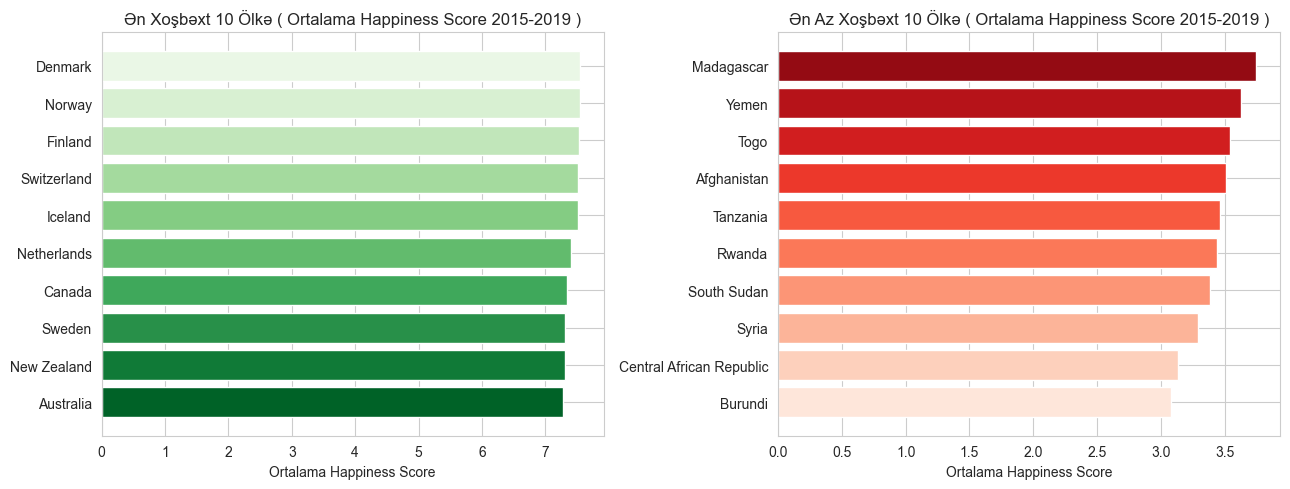

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top10.index[::-1], top10.values[::-1], color=sns.color_palette('Greens_r', 10))
axes[0].set_title('Ən Xoşbəxt 10 Ölkə ( Ortalama Happiness Score 2015-2019 )')
axes[0].set_xlabel('Ortalama Happiness Score')
axes[1].barh(bottom10.index[::-1], bottom10.values[::-1], color=sns.color_palette('Reds', 10))
axes[1].set_title('Ən Az Xoşbəxt 10 Ölkə ( Ortalama Happiness Score 2015-2019 )')
axes[1].set_xlabel('Ortalama Happiness Score')
plt.tight_layout()
plt.savefig('top_bottom10.png', dpi=150)
plt.show()

In [6]:
factors = ['GDP', 'SocialSupport', 'Health', 'Freedom', 'Generosity', 'Corruption']
corrs = full[factors + ['HappinessScore']].corr()['HappinessScore'].drop('HappinessScore')
corrs = corrs.sort_values(ascending=False)
print(corrs)

GDP              0.789284
Health           0.742456
SocialSupport    0.648799
Freedom          0.551258
Corruption       0.398027
Generosity       0.137578
Name: HappinessScore, dtype: float64


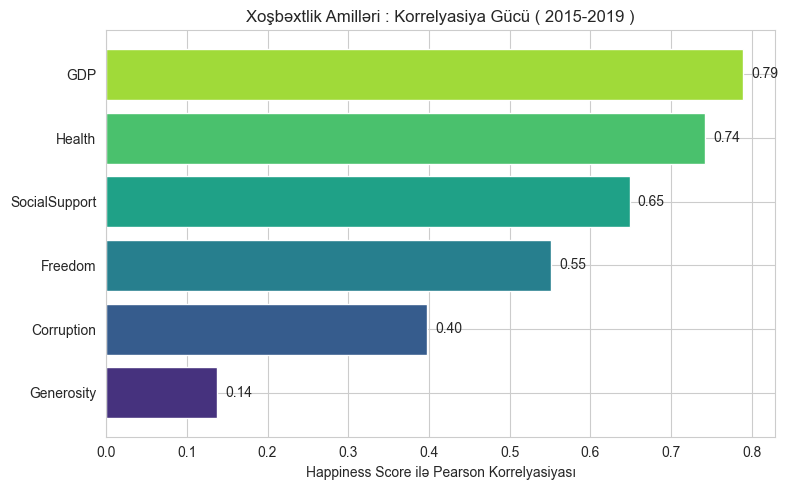

In [7]:
corrs_sorted = corrs.sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('viridis', len(corrs_sorted))
ax.barh(corrs_sorted.index, corrs_sorted.values, color=colors)
ax.set_xlabel('Happiness Score ilə Pearson Korrelyasiyası')
ax.set_title('Xoşbəxtlik Amilləri : Korrelyasiya Gücü ( 2015-2019 )')
for i, v in enumerate(corrs_sorted.values):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center')
plt.tight_layout()
plt.savefig('correlation_chart.png', dpi=150)
plt.show()

In [8]:
counts = full.groupby('Country')['Year'].nunique()
countries_all5 = counts[counts == 5].index
print('Countries present in all 5 years:', len(countries_all5))
sub = full[full['Country'].isin(countries_all5)]
piv = sub.pivot_table(index='Country', columns='Year', values='HappinessScore')
piv['Change'] = piv[2019] - piv[2015]
risers = piv['Change'].sort_values(ascending=False).head(5)
fallers = piv['Change'].sort_values().head(5)
print('TOP 5 RISERS:'); print(risers)
print('\nTOP 5 FALLERS:'); print(fallers)

Countries present in all 5 years: 145
TOP 5 RISERS:
Country
Benin           1.543
Ivory Coast     1.289
Togo            1.246
Honduras        1.072
Burkina Faso    1.000
Name: Change, dtype: float64

TOP 5 FALLERS:
Country
Venezuela   -2.103
Zambia      -1.022
Zimbabwe    -0.947
Haiti       -0.921
Malawi      -0.882
Name: Change, dtype: float64


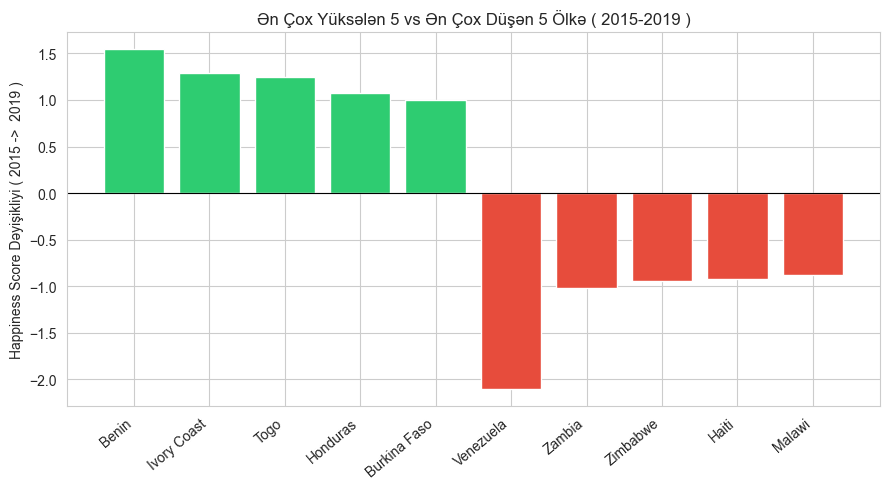

In [12]:
combined_rf = pd.concat([risers, fallers])
colors_rf = ['#2ecc71'] * 5 + ['#e74c3c'] * 5
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(combined_rf.index, combined_rf.values, color=colors_rf)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Happiness Score Dəyişikliyi ( 2015 ->  2019 )')
ax.set_title('Ən Çox Yüksələn 5 vs Ən Çox Düşən 5 Ölkə ( 2015-2019 )')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('risers_fallers.png', dpi=150)
plt.show()

In [13]:
top20 = piv.drop(columns='Change').mean(axis=1).sort_values(ascending=False).head(20).index
pivot20 = piv.loc[top20].drop(columns='Change').round(3)
pivot20

Year,2015,2016,2017,2018,2019
Country,,,,,
Denmark,7.527,7.526,7.522,7.555,7.600
Norway,7.522,7.498,7.537,7.594,7.554
Finland,7.406,7.413,7.469,7.632,7.769
Switzerland,7.587,7.509,7.494,7.487,7.480
Iceland,7.561,7.501,7.504,7.495,7.494
Netherlands,7.378,7.339,7.377,7.441,7.488
Canada,7.427,7.404,7.316,7.328,7.278
Sweden,7.364,7.291,7.284,7.314,7.343
New Zealand,7.286,7.334,7.314,7.324,7.307


Region
Australia and New Zealand          7.294600
North America                      7.174700
Western Europe                     6.740590
Latin America and Caribbean        6.023811
Eastern Asia                       5.651567
Central and Eastern Europe         5.428875
Middle East and Northern Africa    5.337208
Southeastern Asia                  5.335227
Southern Asia                      4.580657
Sub-Saharan Africa                 4.188482
Name: HappinessScore, dtype: float64


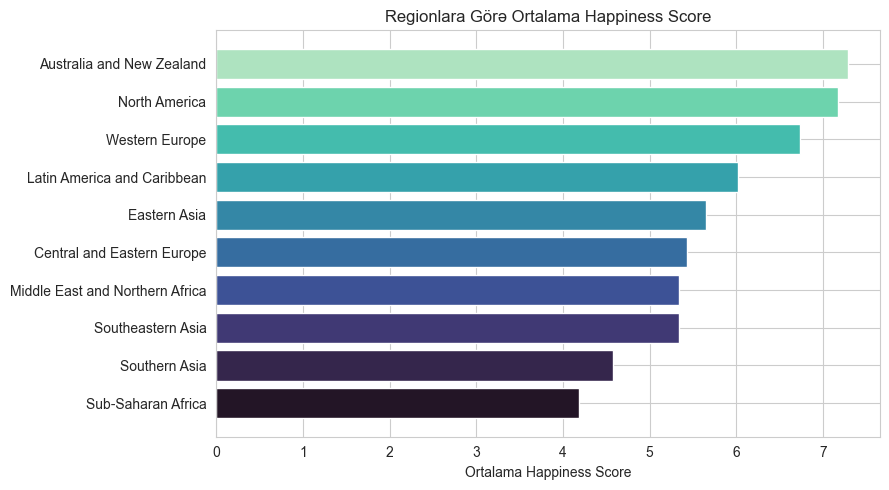

In [14]:
region_avg = full.dropna(subset=['Region']).groupby('Region')['HappinessScore'].mean().sort_values(ascending=False)
print(region_avg)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(region_avg.index[::-1], region_avg.values[::-1], color=sns.color_palette('mako', len(region_avg)))
ax.set_xlabel('Ortalama Happiness Score')
ax.set_title('Regionlara Görə Ortalama Happiness Score')
plt.tight_layout()
plt.savefig('region_avg.png', dpi=150)
plt.show()

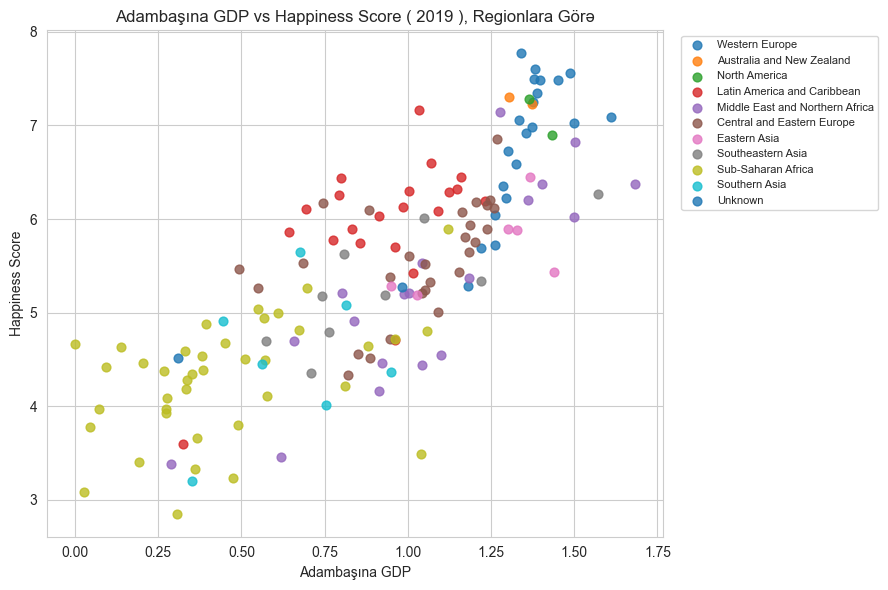

In [15]:
d19_std = full[full['Year'] == 2019].copy()
fig, ax = plt.subplots(figsize=(9, 6))
regions = d19_std['Region'].fillna('Unknown').unique()
palette = sns.color_palette('tab10', len(regions))
for reg, col in zip(regions, palette):
    s = d19_std[d19_std['Region'].fillna('Unknown') == reg]
    ax.scatter(s['GDP'], s['HappinessScore'], label=reg, color=col, s=40, alpha=0.8)
ax.set_xlabel('Adambaşına GDP')
ax.set_ylabel('Happiness Score')
ax.set_title('Adambaşına GDP vs Happiness Score ( 2019 ), Regionlara Görə')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('gdp_vs_happiness_2019.png', dpi=150)
plt.show()

In [16]:
gen_q75 = full['Generosity'].quantile(0.75)
score_q25 = full['HappinessScore'].quantile(0.25)
outliers = full[(full['Generosity'] > gen_q75) & (full['HappinessScore'] < score_q25)]
outliers_sorted = outliers[['Country', 'Year', 'Generosity', 'HappinessScore']].sort_values('Generosity', ascending=False)
print('Outlier rows:', len(outliers_sorted))
outliers_sorted.head(15)

Outlier rows: 41


,Country,Year,Generosity,HappinessScore
276,Myanmar,2016,0.819710,4.395
128,Myanmar,2015,0.795880,4.307
599,Myanmar,2018,0.598000,4.308
756,Myanmar,2019,0.566000,4.360
466,Syria,2017,0.493664,3.462
434,Sri Lanka,2017,0.490864,4.440
459,Haiti,2017,0.489204,3.603
313,Syria,2016,0.483970,3.069
293,Haiti,2016,0.479580,4.028
155,Syria,2015,0.471790,3.006
